In [1]:
import torch
# Automatically pull the correct pre-compiled binaries for your exact environment
!pip install -q torch_geometric
!pip install -q networkx
!pip install -q pyg-lib torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-{torch.__version__}.html
!pip install -q optuna
!pip install -q mlflow
print("\n" + "="*50 + "\nCRITICAL STEP: Go to the top menu, select 'Runtime' -> 'Restart session',\nthen run the cells from cell 2 downwards!\n" + "="*50)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 15.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 28.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 681.6/681.6 kB 38.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 43.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 8.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 87.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 95.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 63.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/1

In [2]:
import sys
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    %cd /content/drive/MyDrive/GNN_Practice

Mounted at /content/drive
/content/drive/MyDrive/GNN_Practice


In [3]:
import mlflow

# The set_experiment API creates a new experiment if it doesn't exist.
mlflow.set_experiment("Cora GNN Experiment")

# IMPORTANT: Enable system metrics monitoring
mlflow.config.enable_system_metrics_logging()
mlflow.config.set_system_metrics_sampling_interval(1)

2026/06/17 23:15:49 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/17 23:15:49 INFO mlflow.store.db.utils: Updating database tables
2026/06/17 23:15:54 INFO mlflow.tracking.fluent: Experiment with name 'Cora GNN Experiment' does not exist. Creating a new experiment.


In [4]:
import numpy as np

import torch
import torch.optim as optim
import torch.nn.functional as F

from torch_geometric.datasets import Planetoid
from torch_geometric.loader import NeighborLoader

import torch.nn as nn
from torch_geometric.nn import GCNConv

import matplotlib.pyplot as plt
import seaborn as sns

# Importing sklearn for computing class weight
from sklearn.utils.class_weight import compute_class_weight

# Importing perfromace metrics
from sklearn.metrics import f1_score, classification_report, confusion_matrix

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Importing tqdm for prgress bar
from tqdm import tqdm

# Import optuna for hyperparameter tuning
import optuna

import copy

# Setting up necessary seeds for reproducibility across runs.
seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
torch.backends.cudnn.benchmark=False
torch.use_deterministic_algorithms(True)

In [5]:
dataset = Planetoid(root='/tmp/Cora', name='Cora')
data = dataset[0]

Processing...
Done!


In [26]:
# Create a loader that samples subgraphs
train_loader = NeighborLoader(
    data,
    num_neighbors=[10, 10],
    batch_size=32,
    input_nodes=data.train_mask,
    shuffle=True
)

val_loader = NeighborLoader(
    data,
    num_neighbors=[-1],
    batch_size=32,
    input_nodes=data.val_mask,
    shuffle=True
)

test_loader = NeighborLoader(
    data,
    num_neighbors=[-1],
    batch_size=32,
    input_nodes=data.test_mask,
    shuffle=True
)

In [7]:
y_train = data.y[data.train_mask]
y_train_np = np.array(y_train)

# compute class weight
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_np),
    y=y_train_np
)

# Defining weight tensor on device
weight_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

In [ ]:
def gnn_validate_parameters(
    in_channels: int,
    hidden_channels: int,
    out_channels: int,
    num_layers: int,
    bnorms: list,
    activations: list,
    dropout_p: list
) -> bool:
    """
    A validator function to ensure GNN arguments conform to the necessary format.
    Assumes standard message-passing layers where hidden structures span across
    the architecture.
    """

    # Validate Scalar Structural Arguments
    if not isinstance(in_channels, int) or in_channels <= 0:
        raise ValueError("'in_channels' must be a positive integer.")

    if not isinstance(hidden_channels, int) and not isinstance(hidden_channels, list):
        raise ValueError("'hidden_channels' must be a positive integer or list.")
    if isinstance(hidden_channels, int):
        if hidden_channels <= 0:
            raise ValueError("'hidden_channels' must be a positive integer.")

    if not isinstance(out_channels, int) or out_channels <= 0:
        raise ValueError("'out_channels' must be a positive integer.")

    if not isinstance(num_layers, int) or num_layers < 1:
        raise ValueError("'num_layers' must be an integer greater than or equal to 1.")

    # Validate Layer Configuration Lists

    expected_length = num_layers - 1

    checks = {
        "bnorms": (bnorms, expected_length),
        "activations": (activations, expected_length),
        "dropout_p": (dropout_p, expected_length)
    }

    for name, (lst, exp_len) in checks.items():
        if not isinstance(lst, list):
            raise TypeError(f"'{name}' must be a list.")
        if len(lst) != exp_len:
            raise ValueError(f"Length of '{name}' ({len(lst)}) must match 'num_layers - 1' = ({exp_len}).")

    # 4. Content Validation

    # Define Allowed Activation Classes (O(1) lookup speed)
    valid_activations = {
        nn.ReLU, nn.Sigmoid, nn.Tanh, nn.Softmax, nn.LogSoftmax, nn.GELU,
        nn.LeakyReLU, nn.ELU, nn.SELU, nn.Hardtanh, nn.Hardsigmoid,
        nn.Hardswish, nn.SiLU, nn.Mish, nn.PReLU
    }

    # Validate Activations
    for i, act in enumerate(activations):
        if act is not None and act not in valid_activations:
            raise ValueError(
                f"Invalid activation at layer index {i}: {act}. "
                f"Must be a torch.nn class (e.g., nn.ReLU) or None."
            )

    # Validate Batch Normalization booleans
    for i, bn in enumerate(bnorms):
        if not isinstance(bn, bool):
            raise TypeError(f"Element at 'bnorms' index {i} must be a boolean.")

    # Validate Dropout Probabilities
    for i, p in enumerate(dropout_p):
        if not isinstance(p, (int, float)):
            raise TypeError(f"Element at 'dropout_p' index {i} must be a float or int.")
        if not (0.0 <= p < 1.0):
            raise ValueError(f"Dropout probability at index {i} ({p}) must be in the range [0, 1).")

    return True

In [ ]:
class GCN(torch.nn.Module):
    def __init__(self,
                 in_channels,
                 hidden_channels,
                 out_channels,
                 num_layers=1,
                 bnorms=None,
                 activations=nn.ReLU,
                 dropout_p=None
                 ):
        super().__init__()

        # Mandatory parameters
        self.in_channels = in_channels
        self.hidden_channels = hidden_channels
        self.out_channels = out_channels

        nblocks = num_layers - 1

        # 1. FIX: Handle strings, lists, AND single classes safely
        if isinstance(activations, str):
            if activations.lower() == 'relu':
                parsed_activations = [nn.ReLU] * nblocks
            elif activations.lower() == 'elu':
                parsed_activations = [nn.ELU] * nblocks
        elif not isinstance(activations, list):
            # If it's a single class like nn.ReLU, turn it into a list
            parsed_activations = [activations] * nblocks
        else:
            parsed_activations = activations

        def get_param(param, default_val, length):
            if param is None:
                param = [default_val] * length
            return param

        self.bnorms = get_param(bnorms, False, nblocks)
        self.activations = get_param(parsed_activations, nn.ReLU, nblocks)
        self.dropout_p = get_param(dropout_p, 0.0, nblocks)

        gnn_validate_parameters(
            in_channels=in_channels,
            hidden_channels=hidden_channels,
            out_channels=out_channels,
            num_layers=num_layers,
            bnorms=self.bnorms,
            activations=self.activations,
            dropout_p=self.dropout_p
        )

        if isinstance(hidden_channels, int):
            hidden_list = [hidden_channels] * nblocks
        else:
            hidden_list = hidden_channels

        # Combine into one perfectly flat list (e.g., [16, 64, 64, 4])
        channels = [in_channels] + hidden_list + [out_channels]

        self.layers = torch.nn.ModuleList()

        for i in range(len(channels) - 1):
            self.layers.append(GCNConv(channels[i], channels[i+1]))

            # Check if we are at the last layer transition
            in_last_layer = (i == len(channels) - 2)

            if not in_last_layer:
                if self.bnorms[i] == True:
                    bnorm = nn.BatchNorm1d(channels[i+1])
                    self.layers.append(bnorm)

                activation = self.activations[i]
                if activation is not None:
                    self.layers.append(activation())

                dropout = nn.Dropout(self.dropout_p[i])
                self.layers.append(dropout)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        for layer in self.layers:
            if isinstance(layer, GCNConv):
                x = layer(x, edge_index)
            else:
                x = layer(x)

        return F.log_softmax(x, dim=1)

In [ ]:
class GNNTrainer:
    """
    A helper class to manage training and validation loops for a PyTorch Geometric GNN.

    Attributes:
        model (torch.nn.Module): The GNN to train.
        optimizer (torch.optim.Optimizer): The optimizer (e.g., Adam, SGD).
        criterion (callable): The loss function (e.g., nn.NLLLoss or nn.CrossEntropyLoss).
        device (torch.device): The device to run training on (CPU or CUDA).
    """
    def __init__(self, model, optimizer, criterion, l1_lambda, l2_lambda, device, metric=None, metric_kws=None):
        """
        Initializes the Trainer with model components.
        """
        self.model = model
        self.optimizer = optimizer
        self.criterion = criterion
        self.l1_lambda = l1_lambda
        self.l2_lambda = l2_lambda
        self.device = device
        self.metric = metric
        self.metric_kws = metric_kws if metric_kws is not None else {}

    def train_one_epoch(self, train_loader):
        """
        Trains the model for one full pass over the training dataset.

        Args:
            train_loader (torch_geometric.loader.DataLoader): Iterator for PyG Data batches.

        Returns:
            tuple: (Computed training score, Average training loss for this epoch)
        """
        self.model.train() # Set model to training mode
        total_loss = 0.0

        all_y_hat = []
        all_y = []

        for batch_idx, data in enumerate(train_loader):
            # PyG dataloaders yield a single 'data' object containing x, edge_index, y, etc.
            data = data.to(self.device)

            # Zero gradients
            self.optimizer.zero_grad()

            # Forward pass (Your GCN expects the whole data object)
            y_hat = self.model(data)

            # Classification loss
            # Note: If your target is 1D, make sure data.y matches the required shape
            classification_loss = self.criterion(y_hat, data.y)

            # Calculate l1 regularization (Safely initialized to 0.0)
            l1_norm = 0.0
            if self.l1_lambda > 0:
                l1_norm = sum(p.abs().sum() for p in self.model.parameters())

            # Calculate l2 regularization (Safely initialized to 0.0)
            l2_norm = 0.0
            if self.l2_lambda > 0:
                l2_norm = sum(p.pow(2).sum() for p in self.model.parameters())

            # Compute regularization loss
            reg_loss = (self.l1_lambda * l1_norm) + (self.l2_lambda * l2_norm)

            loss = classification_loss + reg_loss

            # Store predictions and targets for metric calculation
            all_y_hat.extend(y_hat.argmax(dim=1).cpu().numpy())
            all_y.extend(data.y.cpu().numpy())

            # Backward pass (compute gradients)
            loss.backward()

            # Update weights
            self.optimizer.step()

            # Accumulate total loss
            total_loss += loss.item()

        # Return average loss over the batches (Fixed bug from CNN code)
        avg_loss = total_loss / len(train_loader)

        # Safely compute score if a metric was provided
        score = None
        if self.metric:
            score = self.metric(all_y, all_y_hat, **self.metric_kws)

        return score, avg_loss

    def validate(self, val_loader):
        """
        Evaluates the model on the validation dataset.

        Args:
            val_loader (torch_geometric.loader.DataLoader): Iterator for validation data.

        Returns:
            tuple: (Computed validation score, Average validation loss)
        """
        self.model.eval() # Set model to evaluation mode

        all_preds = []
        all_targets = []
        total_val_loss = 0.0

        with torch.no_grad(): # Disable gradient calculation
            for data in val_loader:
                # Move data to GPU/CPU
                data = data.to(self.device)

                # Forward pass
                output = self.model(data)

                # Calculate loss
                val_loss = self.criterion(output, data.y)
                total_val_loss += val_loss.item()

                # Get predicted class indices
                preds = output.argmax(dim=1)

                # Store predictions and targets for batch
                all_preds.extend(preds.cpu().numpy())
                all_targets.extend(data.y.cpu().numpy())

        # Compute metric
        score = None
        if self.metric:
            score = self.metric(all_targets, all_preds, **self.metric_kws)

        avg_val_loss = total_val_loss / len(val_loader)

        return score, avg_val_loss

In [ ]:
class GNNObjective:
    def __init__(self,
                 train_loader,
                 val_loader,
                 in_channels,
                 n_classes,
                 class_weights,
                 device,
                 nepoch,
                 patience,
                 grace):
        """
        Args:
            train_loader: PyG DataLoader for training graphs
            val_loader: PyG DataLoader for validation graphs
            in_channels: Integer number of input node features
            n_classes: Integer number of output classes (out_channels)
            device: torch.device('cuda' or 'cpu')
        """
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.in_channels = in_channels
        self.out_channels = n_classes
        self.device = device
        self.class_weights = class_weights
        self.nepoch = nepoch
        self.patience = patience
        self.grace = grace

    def __call__(self, trial):
        # --- 1. Hyperparameter Search Space ---

        # A. GNN Layer Configuration
        num_layers = trial.suggest_int("num_layers", 2, 5)

        # We can keep hidden_channels uniform across layers for simplicity,
        # or suggest a list. Let's use a uniform size chosen from a discrete list.
        hidden_channels = trial.suggest_categorical("hidden_channels", [16, 32, 64, 128, 256])

        nblocks = num_layers - 1 # Number of hidden transitions

        bnorms = []
        activations = []
        dropout_p = []

        # Dictionaries to map string suggestions to actual PyTorch Classes
        act_map = {"relu": nn.ReLU, "leaky": nn.LeakyReLU, "elu": nn.ELU}

        for i in range(nblocks):
            # Suggest params for THIS specific hidden layer
            bnorms.append(trial.suggest_categorical(f"bnorm_{i}", [True, False]))

            act_name = trial.suggest_categorical(f"act_{i}", ["relu", "leaky", "elu"])
            activations.append(act_map[act_name])

            dropout_p.append(trial.suggest_float(f"dropout_{i}", 0.0, 0.6))

        # Optimizer Configuration
        optim_lr = trial.suggest_float("optim_lr", 1e-4, 5e-2, log=True)
        optimizer_name = "Adam" # Can be made categorical later if desired

        # --- 2. Model Instantiation ---

        try:
            self.model = GCN(
                in_channels=self.in_channels,
                hidden_channels=hidden_channels,
                out_channels=self.out_channels,
                num_layers=num_layers,
                bnorms=bnorms,
                activations=activations,
                dropout_p=dropout_p
            ).to(self.device)

        except (RuntimeError, ValueError) as e:
            print(f"Trial {trial.number} Pruned due to invalid architecture: {e}")
            raise optuna.exceptions.TrialPruned()

        # --- 3. Trainer & Optimizer Setup ---

        # Note: If your GCN outputs F.log_softmax, you should use nn.NLLLoss().
        # If it outputs raw logits, use nn.CrossEntropyLoss().
        criterion = nn.NLLLoss(weight=self.class_weights)

        if optimizer_name == "Adam":
            optimizer = optim.Adam(self.model.parameters(), lr=optim_lr)
        elif optimizer_name == "RMSprop":
            optimizer = optim.RMSprop(self.model.parameters(), lr=optim_lr)
        else:
            optimizer = optim.SGD(self.model.parameters(), lr=optim_lr, momentum=0.9)

        # Suggest Regularization Strengths
        l1_lambda = trial.suggest_float("l1_lambda", 1e-6, 1e-2, log=True)
        l2_lambda = trial.suggest_float("l2_lambda", 1e-6, 1e-2, log=True)

        trainer = GNNTrainer(self.model,
                             optimizer,
                             criterion,
                             l1_lambda,
                             l2_lambda,
                             self.device,
                             f1_score,
                             metric_kws={'average': 'weighted'})

        # --- 4. Training Loop ---

        pbar = tqdm(
            range(self.nepoch),
            desc=f"Trial {trial.number if trial else 'N/A'}",
            leave=True
        )

        best_f1 = -float('inf')
        patience_counter = 0
        best_epoch = 0

        with mlflow.start_run() as run:                                          # mlflow

            mlflow.log_params(trial.params)                                      #mlflow
            # mlflow.pytorch.log_model(self.model, name=f"trial_{trial.number}")

            for iepoch in pbar:
                # Train
                train_f1, train_loss = trainer.train_one_epoch(self.train_loader)

                # Validate
                val_f1, val_loss = trainer.validate(self.val_loader)

                # Early Stopping & Best Score Tracking
                if val_f1 > best_f1:
                    best_f1 = val_f1
                    best_epoch = iepoch
                    patience_counter = 0
                else:
                    if iepoch > self.grace:
                        patience_counter += 1
                        if patience_counter >= self.patience:
                            print(f'No progress for {self.patience} epochs. '
                                f'Early stopping training at epoch {iepoch} for trial {trial.number}')
                            break

                # Log epoch metrics                                               # mlflow
                mlflow.log_metrics(
                    {
                        "train_loss": train_loss,
                        "train_f1": train_f1,
                        "val_loss": val_loss,
                        "val_f1": val_f1,
                    },
                    step=iepoch,
                )

                mlflow.pytorch.log_model(self.model, name=f"checkpoint_{iepoch}")

                # Report to Optuna
                trial.report(val_f1, iepoch)

                # Pruning (Stop bad trials early)
                if trial.should_prune():
                    raise optuna.exceptions.TrialPruned()

            # Log the final trained model
            model_info = mlflow.pytorch.log_model(self.model, name="final_model")

        print(f'Trial {trial.number} finished. Best epoch: {best_epoch}')
        return best_f1

In [ ]:
# Setup Data
in_channels = data.num_features
n_classes = len(np.unique(data.y[data.train_mask]))
nepoch = 100

# Early stoping criteria
patience = 20
grace = 20

# Initialize Objective
objective = GNNObjective(
    train_loader,
    val_loader,
    in_channels,
    n_classes,
    weight_tensor,
    device,
    nepoch,
    patience,
    grace
)

storage_path = "sqlite:///optuna_studies/cora_gcn_study.db"
study_name = "cora_gcn"

# Create Study
study = optuna.create_study(
    direction="maximize",
    pruner=optuna.pruners.HyperbandPruner(min_resource=5, max_resource=nepoch),
    sampler=optuna.samplers.TPESampler(seed),
    storage=storage_path,
    study_name=study_name,
    load_if_exists=True
)

n_trials = 50
# Optimize
if len(study.trials) <= n_trials:
    print("Starting optimization...")
    study.optimize(objective, n_trials=n_trials)

/tmp/ipykernel_13721/1577115100.py:30: FutureWarning: __init__() got {'consider_prior'} as positional arguments but they were expected to be given as keyword arguments.
Positional arguments ['self', 'consider_prior', 'prior_weight', 'consider_magic_clip', 'consider_endpoints', 'n_startup_trials', 'n_ei_candidates', 'gamma', 'weights', 'seed'] in __init__() have been deprecated since v4.4.0. They will be replaced with the corresponding keyword arguments in v6.0.0, so please use the keyword specification instead. See https://github.com/optuna/optuna/releases/tag/v4.4.0 for details.
  sampler=optuna.samplers.TPESampler(seed),
/tmp/ipykernel_13721/1577115100.py:30: FutureWarning: `consider_prior` has been deprecated in v4.3.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.3.0.
  sampler=optuna.samplers.TPESampler(seed),
[I 2026-06-16 10:37:14,890] Using an existing study with name 'cora_gcn' instead of creating a new one.


Starting optimization...


Trial 0: 100%|██████████| 100/100 [00:17<00:00,  5.78it/s]
[I 2026-06-16 10:37:33,261] Trial 0 finished with value: 0.6755779494466227 and parameters: {'num_layers': 2, 'hidden_channels': 16, 'bnorm_0': False, 'act_0': 'elu', 'dropout_0': 0.11881589768598334, 'optim_lr': 0.00010548852958872417, 'l1_lambda': 0.0023786085556943997, 'l2_lambda': 0.00010223671020415584}. Best is trial 0 with value: 0.6755779494466227.


Trial 0 finished. Best epoch: 98


Trial 1: 100%|██████████| 100/100 [00:33<00:00,  2.99it/s]
[I 2026-06-16 10:38:07,346] Trial 1 finished with value: 0.897037760275144 and parameters: {'num_layers': 5, 'hidden_channels': 64, 'bnorm_0': True, 'act_0': 'elu', 'dropout_0': 0.5308231098203439, 'bnorm_1': True, 'act_1': 'leaky', 'dropout_1': 0.2574300845679782, 'bnorm_2': True, 'act_2': 'elu', 'dropout_2': 0.2948773286226844, 'bnorm_3': True, 'act_3': 'leaky', 'dropout_3': 0.24576085244678952, 'optim_lr': 0.000693211635694237, 'l1_lambda': 0.00016160009332435917, 'l2_lambda': 7.672319652552048e-05}. Best is trial 1 with value: 0.897037760275144.


...

No progress for 20 epochs. Early stopping training at epoch 63 for trial 38
Trial 38 finished. Best epoch: 43


Trial 39:   5%|▌         | 5/100 [00:02<00:44,  2.15it/s]
[I 2026-06-16 10:48:50,420] Trial 39 pruned. 
Trial 40:   5%|▌         | 5/100 [00:01<00:30,  3.09it/s]
[I 2026-06-16 10:48:52,477] Trial 40 pruned. 
Trial 41:   5%|▌         | 5/100 [00:02<00:38,  2.48it/s]
[I 2026-06-16 10:48:55,255] Trial 41 pruned. 
Trial 42:  15%|█▌        | 15/100 [00:06<00:37,  2.27it/s]
[I 2026-06-16 10:49:02,562] Trial 42 pruned. 
Trial 43:   5%|▌         | 5/100 [00:02<00:38,  2.46it/s]
[I 2026-06-16 10:49:05,334] Trial 43 pruned. 
Trial 44:   5%|▌         | 5/100 [00:02<00:43,  2.17it/s]
[I 2026-06-16 10:49:08,512] Trial 44 pruned. 
Trial 45:   5%|▌         | 5/100 [00:02<00:46,  2.03it/s]
[I 2026-06-16 10:49:11,697] Trial 45 pruned. 
Trial 46:   5%|▌         | 5/100 [00:01<00:29,  3.25it/s]
[I 2026-06-16 10:49:13,979] Trial 46 pruned. 
Trial 47:  70%|███████   | 70/100 [00:29<00:12,  2.36it/s]
[I 2026-06-16 10:49:44,634] Trial 47 finished with value: 0.9027716786035783 and parameters: {'num_layers': 

No progress for 20 epochs. Early stopping training at epoch 70 for trial 47
Trial 47 finished. Best epoch: 50


Trial 48:   5%|▌         | 5/100 [00:01<00:31,  3.04it/s]
[I 2026-06-16 10:49:47,034] Trial 48 pruned. 
Trial 49:  40%|████      | 40/100 [00:13<00:20,  2.97it/s]
[I 2026-06-16 10:50:01,123] Trial 49 finished with value: 0.9058113296575904 and parameters: {'num_layers': 3, 'hidden_channels': 128, 'bnorm_0': False, 'act_0': 'relu', 'dropout_0': 0.3745209917280866, 'bnorm_1': False, 'act_1': 'relu', 'dropout_1': 0.265753792629609, 'optim_lr': 0.020752918744999536, 'l1_lambda': 1.591682165899745e-06, 'l2_lambda': 2.731224117879239e-05}. Best is trial 16 with value: 0.9097132102290517.


No progress for 20 epochs. Early stopping training at epoch 40 for trial 49
Trial 49 finished. Best epoch: 19


In [ ]:
print("Best Parameters:")
study.best_params

Best Parameters:


{'num_layers': 3,
 'hidden_channels': 256,
 'bnorm_0': True,
 'act_0': 'relu',
 'dropout_0': 0.4392756836581714,
 'bnorm_1': False,
 'act_1': 'leaky',
 'dropout_1': 0.3430721075981166,
 'optim_lr': 0.015748507191133663,
 'l1_lambda': 2.181040881770844e-05,
 'l2_lambda': 3.279633771741911e-05}

In [ ]:
best_params = study.best_params

# Activation and pooling layers map
act_map = {"relu": nn.ReLU, "leaky": nn.LeakyReLU, "elu": nn.ELU}
pool_map = {"max": nn.MaxPool2d, "avg": nn.AvgPool2d, "none": None}

# Extracting Prameters from best_params
num_layers = best_params["num_layers"]
hidden_channels = best_params["hidden_channels"]
nblocks = num_layers - 1

bnorms = []
activations = []
dropout_p = []

for i in range(nblocks):
    bnorms.append(best_params[f"bnorm_{i}"])
    activations.append(act_map[best_params[f"act_{i}"]])
    dropout_p.append(best_params[f"dropout_{i}"])

optim_lr = best_params['optim_lr']
l1_lambda = best_params['l1_lambda']
l2_lambda = best_params['l2_lambda']

nepoch =  100

# Definin the best gcn model
CoraGCN = GCN(
    in_channels=data.num_features,
    hidden_channels=hidden_channels,
    out_channels=n_classes,
    num_layers=num_layers,
    bnorms=bnorms,
    activations=activations,
    dropout_p=dropout_p
).to(device)

# Defining optimizer and criterion
optimizer = optim.Adam(CoraGCN.parameters(), lr=optim_lr)
criterion = nn.NLLLoss(weight=weight_tensor)

trainer = GNNTrainer(CoraGCN,
                     optimizer,
                     criterion,
                     l1_lambda,
                     l2_lambda,
                     device,
                     f1_score,
                     metric_kws = {'average':'weighted'})

# Registering losses and f1s for furthur visualization
train_f1s = []
val_f1s = []
train_losses = []
val_losses = []
best_f1 = -float('inf')

# progress bar
pbar = tqdm(range(nepoch),
            leave=True)

for iepoch in pbar:
    # Train for one epoch and get f1 score and train loss
    train_f1, train_loss = trainer.train_one_epoch(train_loader)
    train_f1s.append(train_f1)
    train_losses.append(train_loss)

    # get validation f1 and validation loss
    val_f1, val_loss = trainer.validate(val_loader)
    val_f1s.append(val_f1)
    val_losses.append(val_loss)

    # Get the best f1 score over the epochs
    if val_f1 > best_f1:
        best_f1 = val_f1
        best_state = copy.deepcopy(CoraGCN.state_dict())

# Loading the best parameters
CoraGCN.load_state_dict(best_state)

100%|██████████| 100/100 [00:59<00:00,  1.68it/s]


<All keys matched successfully>

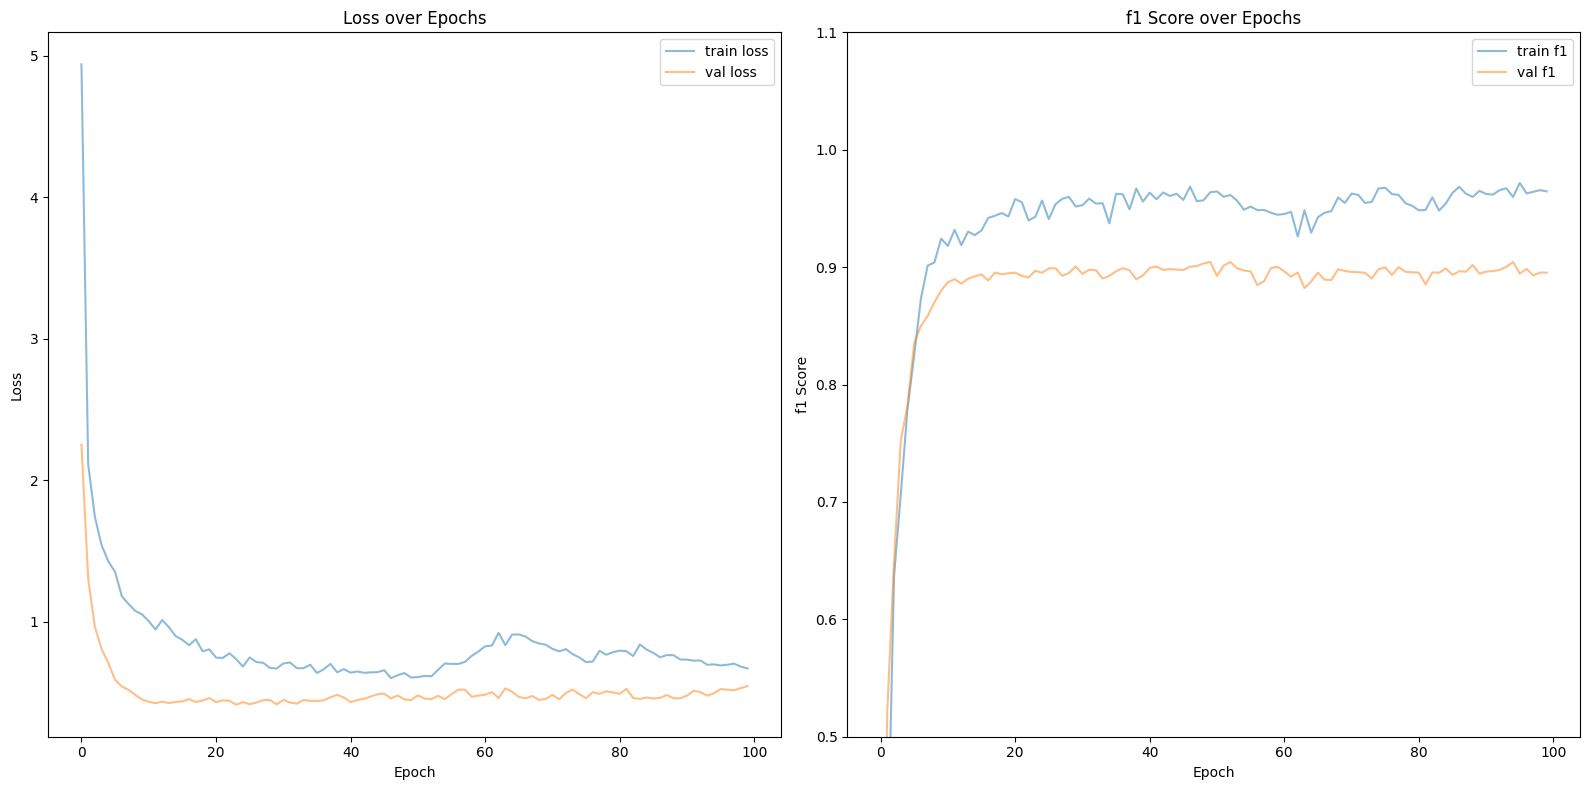

In [ ]:
fig, axes = plt.subplots(1,2,figsize=(16,8))
axes = axes.flatten()

# Determine the range of epochs to plot
betn = (0,nepoch)

# Plot training and val losses
sns.lineplot(x=range(betn[0], betn[1]), y=train_losses[betn[0]:betn[1]], alpha=0.5,ax=axes[0],label='train loss')
sns.lineplot(x=range(betn[0], betn[1]), y=val_losses[betn[0]:betn[1]], alpha=0.5,ax=axes[0],label='val loss')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Plot training and test f1 scores
sns.lineplot(x=range(betn[0], betn[1]), y=train_f1s[betn[0]:betn[1]], alpha=0.5,ax=axes[1], label='train f1')
sns.lineplot(x=range(betn[0], betn[1]), y=val_f1s[betn[0]:betn[1]], alpha=0.5,ax=axes[1], label='val f1')
axes[1].set_ylim(0.5,1.1)
axes[1].set_title('f1 Score over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('f1 Score')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Test socres
CoraGCN.eval() # Set model to evaluation mode

# Register the targets and predictions
all_preds = []
all_targets = []
total_test_loss = 0.0

with torch.no_grad(): # Disable gradient calculation to save memory
    for batch in test_loader: # loop over each test batch
        # Move data to gpu
        data.to(device)

        # forwrd pass
        output = CoraGCN(batch)

        test_loss = criterion(output, batch.y)
        total_test_loss += test_loss.item()

        # Get predicted class indices
        preds = output.argmax(dim=1)

        # Store predictions and targets for batch
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(batch.y.cpu().numpy())

# Compute classification metrics
print(classification_report(all_targets, all_preds))
print(total_test_loss)

              precision    recall  f1-score   support

           0       0.88      0.87      0.88      2151
           1       0.91      0.96      0.93      1458
           2       0.95      0.96      0.96      2307
           3       0.91      0.89      0.90      3629
           4       0.90      0.87      0.88      2008
           5       0.88      0.87      0.87      1491
           6       0.87      0.91      0.89       881

    accuracy                           0.90     13925
   macro avg       0.90      0.90      0.90     13925
weighted avg       0.90      0.90      0.90     13925

14.279016315937042


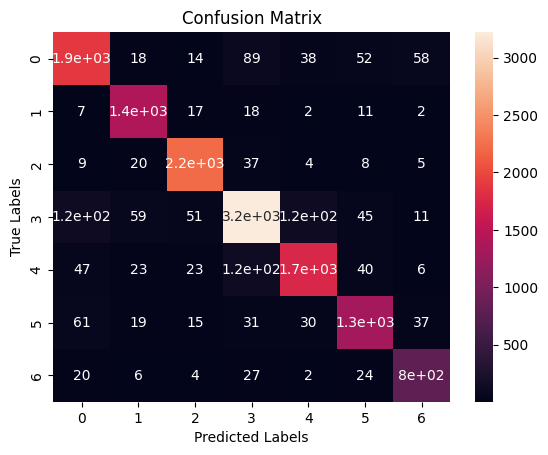

In [ ]:
# calculate confusion matrix
con_mat = confusion_matrix(all_targets, all_preds)

# visulaize confusion matrix
sns.heatmap(con_mat,annot=True)
plt.ylabel('True Labels')
plt.xlabel('Predicted Labels')
plt.title('Confusion Matrix')
plt.show()